# 政策文本分类：LLM Zero-Shot 评估与 Prompt 敏感性分析

## 研究目标

本 notebook 以 578 份中国县级水污染治理政策文本为对象，开展一项**标注一致性研究（annotation agreement study）**，
系统比较规则方法与 LLM zero-shot 分类在政策工具识别上的表现，并引入人工标注作为 ground truth 进行校准。

核心研究问题：
1. **Prompt Sensitivity**: LLM 的分类结果对 prompt 设计有多敏感？哪些文档最不稳定？
2. **Annotator Agreement**: 规则方法与 LLM 作为两个独立 annotator，一致性如何？
3. **Ground Truth Calibration**: 在分歧样本上，哪种方法更接近人工判断？

## 流程概览

| Phase | 内容 | 输出 |
|-------|------|------|
| Phase 1 | 多 Prompt 设计与 Gemini 批量分类 | 每文档 × 8 prompt 的分类结果 |
| Phase 2 | Prompt 敏感性分析 | flip rate, consistency score, 敏感文档识别 |
| Phase 3 | 规则 vs LLM 一致性分析 | Cohen's Kappa, 混淆矩阵, 分歧模式 |
| Phase 4 | 分歧样本导出 → 人工标注 | disagreements_for_annotation.csv |
| Phase 5 | 三方评估（Rule vs LLM vs Human） | 以 human label 为 ground truth 的准确率对比 |

---
# Phase 0: 环境配置与数据加载

In [ ]:
# !pip install google-genai pandas scikit-learn matplotlib seaborn tqdm

In [32]:
import os, json, time, re, hashlib
import pandas as pd
import numpy as np
from collections import Counter
from tqdm import tqdm

from google import genai
from google.genai import types

from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score, f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 如果需要显示中文，安装中文字体：
# !pip install matplotlib-fontcn
# 然后用: matplotlib.rcParams['font.family'] = ['Noto Sans CJK SC']

VALID_LABELS = {"regulatory", "incentive", "informational"}
LABELS = ["regulatory", "incentive", "informational"]

os.makedirs("output", exist_ok=True)
print("环境就绪")

环境就绪


In [ ]:
# ====== Gemini API 配置 ======
GEMINI_API_KEY = "xx"  # <-- 替换为你的 key
client = genai.Client(api_key=GEMINI_API_KEY)
MODEL_NAME = "gemini-2.5-flash"       # 免费层推荐，速度快额度高

In [10]:
# ====== 加载数据 ======
df = pd.read_csv("./output/classify/policy_with_labels.csv")
df = df.dropna(subset=["clean_text"]).reset_index(drop=True)

print(f"有效文档数: {len(df)}")
print(f"\n规则分类分布:")
print(df["tool"].value_counts())
print(f"\n文本长度: 中位数 {df['clean_text'].str.len().median():.0f} 字符")

有效文档数: 575

规则分类分布:
tool
regulatory       517
informational     30
incentive         28
Name: count, dtype: int64

文本长度: 中位数 2570 字符


---
# Phase 1: 多 Prompt 设计与批量分类

设计 **8 个 prompt 变体**，沿 4 个正交维度进行扰动，借鉴 prompt sensitivity 研究范式：

| 维度 | 变化 | 对应 Prompt ID |
|------|------|----------------|
| 指令语言 | 中文 vs 英文 | P1 vs P2 |
| 定义详细度 | 无定义 vs 简短 vs 详细 | P3 vs P1 vs P4 |
| 标签顺序 | R-I-Info vs Info-I-R | P1 vs P5 |
| 角色设定 | 无角色 vs 政策专家 vs 环境学者 | P6 vs P1 vs P7 |
| 输出格式 | JSON vs 单词 | P1 vs P8 |

In [ ]:
# ====================================================================
# 定义 8 个 Prompt 变体
# ====================================================================

PROMPTS = {}

# ------ P1: 基线 Prompt（中文 + 详细定义 + 政策专家 + JSON 输出）------
PROMPTS["P1_baseline_zh"] = {
    "system": (
        "你是一位公共政策分析专家，专注于中国环境治理政策研究。\n\n"
        "你的任务是对水污染治理政策文本进行政策工具分类。政策工具分为以下三类：\n\n"
        "1. **regulatory**（监管型）：依靠行政命令、法规标准、执法检查、处罚整改等强制性手段推动治理。\n"
        "   典型特征：排放标准、执法检查、行政处罚、限期整改、禁止排放、监督管理。\n\n"
        "2. **incentive**（激励型）：通过经济手段引导行为，包括财政补贴、奖励资金、税收优惠、生态补偿等。\n"
        "   典型特征：资金补助、奖励机制、财政扶持、税收减免、生态补偿、以奖代补。\n\n"
        "3. **informational**（信息型）：通过信息传递影响认知与行为，包括宣传教育、技术指导、信息公开等。\n"
        "   典型特征：宣传教育、培训指导、信息公示、科普活动、技术推广。\n\n"
        "分类原则：判断政策文本的**主要/核心工具手段**，而非穷举所有提及的手段。"
    ),
    "user_template": (
        "请对以下政策文本进行分类。\n\n"
        "【政策文本】\n{text}\n\n"
        "请只返回一个JSON对象，格式如下，不要包含任何其他文字：\n"
        '{{"label": "regulatory 或 incentive 或 informational", "reason": "一句话简要理由"}}'
    ),
}

# ------ P2: 英文指令 ------
PROMPTS["P2_english"] = {
    "system": (
        "You are a public policy analyst specializing in Chinese environmental governance.\n\n"
        "Classify the following Chinese policy text into one of three policy instrument types:\n\n"
        "1. **regulatory**: Relies on administrative orders, regulations, enforcement, penalties, "
        "and mandatory compliance mechanisms.\n"
        "2. **incentive**: Uses economic tools such as subsidies, financial rewards, tax benefits, "
        "and ecological compensation to guide behavior.\n"
        "3. **informational**: Relies on information dissemination, public education, technical "
        "guidance, and transparency to influence awareness and behavior.\n\n"
        "Classify based on the DOMINANT instrument, not all mentioned instruments."
    ),
    "user_template": (
        "Classify the following Chinese policy text.\n\n"
        "[Policy Text]\n{text}\n\n"
        "Return ONLY a JSON object, no other text:\n"
        '{{"label": "regulatory or incentive or informational", "reason": "brief reason"}}'
    ),
}

# ------ P3: 无定义（仅标签名）------
PROMPTS["P3_no_definition"] = {
    "system": (
        "你是一位政策分析专家。请将水污染治理政策文本分为以下三类之一：\n"
        "regulatory、incentive、informational。\n"
        "基于政策的主要手段进行分类。"
    ),
    "user_template": (
        "请对以下政策文本进行分类。\n\n"
        "【政策文本】\n{text}\n\n"
        '请只返回JSON：{{"label": "类别", "reason": "理由"}}'
    ),
}

# ------ P4: 超详细定义 + 示例 ------
PROMPTS["P4_detailed_with_examples"] = {
    "system": (
        "你是一位公共政策分析专家。请对水污染治理政策文本进行政策工具分类。\n\n"
        "三类政策工具的定义、典型关键词和示例如下：\n\n"
        "1. **regulatory**（监管型）\n"
        "   定义：政府通过强制性行政手段直接约束和规范污染行为。\n"
        "   关键词：排放标准、执法检查、行政处罚、限期整改、禁止、监督管理、专项整治、达标排放。\n"
        "   示例：《关于开展重点污染源专项执法检查的通知》\n\n"
        "2. **incentive**（激励型）\n"
        "   定义：政府通过经济激励手段引导企业和个人参与治污。\n"
        "   关键词：补贴、奖励、资金扶持、税收优惠、生态补偿、以奖代补、绩效考核奖励。\n"
        "   示例：《农村生活污水治理项目资金补助管理办法》\n\n"
        "3. **informational**（信息型）\n"
        "   定义：政府通过信息传递和教育活动提升公众认知和参与意识。\n"
        "   关键词：宣传、培训、指导、公示、公开、科普、技术推广、信息通报。\n"
        "   示例：《关于开展水环境保护科普宣传月活动的通知》\n\n"
        "注意：多数政策会混合使用多种工具，请判断**主导机制**。\n"
        "如果文本核心是制定补助的管理标准和监督流程，即使涉及'资金''补助'等词，"
        "主导机制仍可能是 regulatory（因为核心目的是规范管理而非直接激励）。"
    ),
    "user_template": (
        "请对以下政策文本进行分类。\n\n"
        "【政策文本】\n{text}\n\n"
        '请只返回JSON：{{"label": "类别", "reason": "理由"}}'
    ),
}

# ------ P5: 标签顺序颠倒（informational 在前）------
PROMPTS["P5_reversed_order"] = {
    "system": (
        "你是一位公共政策分析专家。请对水污染治理政策文本进行政策工具分类。\n\n"
        "政策工具分为以下三类：\n\n"
        "1. **informational**（信息型）：宣传教育、技术指导、信息公开、科普活动。\n\n"
        "2. **incentive**（激励型）：财政补贴、奖励资金、税收优惠、生态补偿。\n\n"
        "3. **regulatory**（监管型）：行政命令、法规标准、执法检查、处罚整改。\n\n"
        "请判断政策的主要工具手段。"
    ),
    "user_template": (
        "请对以下政策文本进行分类。\n\n"
        "【政策文本】\n{text}\n\n"
        '请只返回JSON：{{"label": "类别", "reason": "理由"}}'
    ),
}

# ------ P6: 无角色设定 ------
PROMPTS["P6_no_role"] = {
    "system": (
        "请将以下水污染治理政策文本分类为以下三类之一：\n\n"
        "- regulatory（监管型）：行政命令、法规标准、执法检查、处罚整改等强制性手段。\n"
        "- incentive（激励型）：财政补贴、奖励资金、税收优惠、生态补偿等经济手段。\n"
        "- informational（信息型）：宣传教育、技术指导、信息公开等信息传递手段。\n\n"
        "判断政策的主要工具手段。"
    ),
    "user_template": (
        "请对以下政策文本进行分类。\n\n"
        "【政策文本】\n{text}\n\n"
        '请只返回JSON：{{"label": "类别", "reason": "理由"}}'
    ),
}

# ------ P7: 环境科学研究者角色 ------
PROMPTS["P7_env_scientist"] = {
    "system": (
        "你是一位环境科学研究员，正在对中国县级水污染治理政策进行量化分析。\n"
        "你需要从政策工具（policy instrument）视角对文本进行分类。\n\n"
        "三类工具：\n"
        "- regulatory：以命令控制（command-and-control）为主的强制手段\n"
        "- incentive：以市场激励（market-based instrument）为主的经济手段\n"
        "- informational：以信息传递（information-based instrument）为主的引导手段\n\n"
        "请识别文本的主导政策工具类型。"
    ),
    "user_template": (
        "请分类以下政策文本：\n\n{text}\n\n"
        '只返回JSON：{{"label": "类别", "reason": "理由"}}'
    ),
}

# ------ P8: 仅返回标签（无理由）------
PROMPTS["P8_label_only"] = {
    "system": (
        "你是一位政策分析专家。将水污染治理政策文本分类为：\n"
        "regulatory（监管型）、incentive（激励型）、informational（信息型）。\n"
        "判断主导工具手段。只回答一个词，不要解释。"
    ),
    "user_template": (
        "政策文本：\n{text}\n\n"
        "分类结果（一个词）："
    ),
}

print(f"共设计 {len(PROMPTS)} 个 Prompt 变体:")
for pid in PROMPTS:
    print(f"  {pid}")

共设计 8 个 Prompt 变体:
  P1_baseline_zh
  P2_english
  P3_no_definition
  P4_detailed_with_examples
  P5_reversed_order
  P6_no_role
  P7_env_scientist
  P8_label_only


In [22]:
# ====================================================================
# API 调用核心函数
# ====================================================================

def parse_response(response_text: str, prompt_id: str) -> dict:
    """多层解析策略：strip markdown → JSON → regex → keyword fallback"""
    text = response_text.strip()
    
    # 先剥离 ```json ... ``` 包裹
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    text = text.strip()

    # 策略1: 直接 JSON 解析
    try:
        result = json.loads(text)
        if result.get("label") in VALID_LABELS:
            return result
    except json.JSONDecodeError:
        pass

    # 策略2: 正则提取 JSON 块
    json_match = re.search(r'\{[^{}]*"label"\s*:\s*"([^"]+)"[^{}]*\}', text)
    if json_match:
        try:
            result = json.loads(json_match.group())
            if result.get("label") in VALID_LABELS:
                return result
        except json.JSONDecodeError:
            pass

    # 策略3: P8 单词模式
    text_lower = text.lower().strip().strip('"').strip("'")
    if text_lower in VALID_LABELS:
        return {"label": text_lower, "reason": "(single word)"}

    # 策略4: 关键词兜底
    for label in VALID_LABELS:
        if label in text_lower:
            return {"label": label, "reason": "(keyword fallback)"}

    return {"label": "PARSE_ERROR", "reason": text[:200]}


def classify_single(text: str, prompt_cfg: dict, max_retries: int = 3,
                     max_chars: int = 3000) -> dict:
    """调用 Gemini 对单篇文本分类，含重试 + 超时保护"""
    truncated = text[:max_chars]
    if len(text) > max_chars:
        truncated += "……（文本已截断）"

    user_msg = prompt_cfg["user_template"].format(text=truncated)

    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=user_msg,
                config=types.GenerateContentConfig(
                    system_instruction=prompt_cfg["system"],
                    temperature=0.0,
                    max_output_tokens=500,
                    http_options={"timeout": 30000},  # 30秒超时
                ),
            )
            return parse_response(response.text, "")

        except Exception as e:
            err = str(e)
            if "429" in err or "quota" in err.lower():
                wait = 30 * (attempt + 1)
                print(f"  ⚠ 速率限制，等待 {wait}s ...")
                time.sleep(wait)
            else:
                print(f"  ⚠ 重试 {attempt+1}/{max_retries}: {err[:80]}")
                time.sleep(3)

    return {"label": "API_ERROR", "reason": "max retries"}


# 快速测试
test = classify_single(df["clean_text"].iloc[0], PROMPTS["P1_baseline_zh"])
print("测试结果:", test)

测试结果: {'label': 'regulatory', 'reason': '(keyword fallback)'}


In [24]:
# ====================================================================
# 批量执行：所有文档 × 4 个关键 Prompt 变体
# 支持断点续传 + 中间保存
# ====================================================================

# 只保留 4 个最关键的 prompt（覆盖语言、定义详细度、输出格式）
SELECTED_PROMPTS = {
    "P1_baseline_zh":         PROMPTS["P1_baseline_zh"],         # 基线：中文+详细定义+JSON
    "P2_english":             PROMPTS["P2_english"],             # 语言维度：英文指令
    "P3_no_definition":       PROMPTS["P3_no_definition"],       # 定义维度：无定义
    "P8_label_only":          PROMPTS["P8_label_only"],          # 格式维度：仅返回标签
}

RESULTS_PATH = "output/multi_prompt_results.csv"
SAVE_EVERY = 50
DELAY_SECONDS = 0.1

# 加载已有结果
if os.path.exists(RESULTS_PATH):
    df_done = pd.read_csv(RESULTS_PATH)
    done_keys = set(zip(df_done["doc_idx"], df_done["prompt_id"]))
    all_results = df_done.to_dict("records")
    print(f"已有 {len(done_keys)} 条结果，断点续传...")
else:
    done_keys = set()
    all_results = []

# 构建任务队列（只用 4 个 prompt）
tasks = []
for idx, row in df.iterrows():
    for pid in SELECTED_PROMPTS:
        if (idx, pid) not in done_keys:
            tasks.append((idx, pid, row))

print(f"待执行任务: {len(tasks)} / 总计 {len(df) * len(SELECTED_PROMPTS)}")

# 执行
for i, (idx, pid, row) in enumerate(tqdm(tasks, desc="多 Prompt 分类")):
    result = classify_single(row["clean_text"], SELECTED_PROMPTS[pid])

    all_results.append({
        "doc_idx": idx,
        "filename": row["filename"],
        "rule_label": row["tool"],
        "prompt_id": pid,
        "gemini_label": result["label"],
        "gemini_reason": result.get("reason", ""),
    })

    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")

    time.sleep(DELAY_SECONDS)

# 最终保存
df_all = pd.DataFrame(all_results)
df_all.to_csv(RESULTS_PATH, index=False, encoding="utf-8-sig")
print(f"\n完成！共 {len(df_all)} 条结果 ({len(df)} docs × {len(SELECTED_PROMPTS)} prompts)")

已有 100 条结果，断点续传...
待执行任务: 2200 / 总计 2300


多 Prompt 分类:   2%|▏         | 41/2200 [02:28<2:15:41,  3.77s/it]

  ⚠ 重试 1/3: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp


多 Prompt 分类:  21%|██        | 465/2200 [26:47<1:28:57,  3.08s/it]

  ⚠ 重试 1/3: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently exp


...

  ⚠ 重试 1/3: [Errno 8] nodename nor servname provided, or not known
  ⚠ 重试 2/3: [Errno 8] nodename nor servname provided, or not known
  ⚠ 重试 3/3: [Errno 8] nodename nor servname provided, or not known


多 Prompt 分类:  49%|████▉     | 1079/2200 [1:32:29<25:12:30, 80.95s/it]

  ⚠ 重试 1/3: [Errno 8] nodename nor servname provided, or not known
  ⚠ 重试 2/3: [Errno 8] nodename nor servname provided, or not known
  ⚠ 重试 3/3: [Errno 8] nodename nor servname provided, or not known


多 Prompt 分类: 100%|██████████| 2200/2200 [2:38:28<00:00,  4.32s/it]   


完成！共 2300 条结果 (575 docs × 4 prompts)


---
# Phase 2: Prompt 敏感性分析

核心指标：
- **Per-Prompt Accuracy**: 每个 prompt 变体以规则标签为参考的准确率
- **Per-Document Consistency**: 同一文档在 8 个 prompt 下的标签一致率
- **Flip Rate**: 标签发生变化的比例
- **Prompt Sensitivity Index (PSI)**: 1 - consistency，越高越不稳定

In [28]:
# 加载结果
df_all = pd.read_csv("output/multi_prompt_results.csv")

# 过滤有效标签
df_valid = df_all[df_all["gemini_label"].isin(VALID_LABELS)].copy()
print(f"有效结果: {len(df_valid)} / {len(df_all)}")
print(f"解析失败: {len(df_all) - len(df_valid)}")

有效结果: 2300 / 2300
解析失败: 0


In [26]:
df_all = pd.read_csv("output/multi_prompt_results.csv")
errors = df_all[~df_all["gemini_label"].isin(["regulatory", "incentive", "informational"])]
print(f"解析失败: {len(errors)} 条")
print(errors[["doc_idx", "prompt_id", "gemini_label", "gemini_reason"]].to_string())

解析失败: 17 条
      doc_idx         prompt_id gemini_label gemini_reason
1136      284    P1_baseline_zh    API_ERROR   max retries
1137      284        P2_english    API_ERROR   max retries
1138      284  P3_no_definition    API_ERROR   max retries
1139      284     P8_label_only    API_ERROR   max retries
1140      285    P1_baseline_zh    API_ERROR   max retries
1141      285        P2_english    API_ERROR   max retries
1142      285  P3_no_definition    API_ERROR   max retries
1146      286  P3_no_definition    API_ERROR   max retries
1147      286     P8_label_only    API_ERROR   max retries
1153      288        P2_english    API_ERROR   max retries
1173      293        P2_english    API_ERROR   max retries
1174      293  P3_no_definition    API_ERROR   max retries
1175      293     P8_label_only    API_ERROR   max retries
1176      294    P1_baseline_zh    API_ERROR   max retries
1177      294        P2_english    API_ERROR   max retries
1178      294  P3_no_definition    API_ERROR 

In [27]:
# 重跑失败的 17 条
df_all = pd.read_csv("output/multi_prompt_results.csv")
errors = df_all[df_all["gemini_label"] == "API_ERROR"]

print(f"重跑 {len(errors)} 条失败任务...\n")

# 看看这几篇文档的长度
for idx in errors["doc_idx"].unique():
    print(f"  doc {idx}: {len(df.loc[idx, 'clean_text'])} 字符")

fixed = 0
for i, (row_idx, row) in enumerate(errors.iterrows()):
    doc_idx = row["doc_idx"]
    pid = row["prompt_id"]
    text = df.loc[doc_idx, "clean_text"]
    
    # 对超长文本截断更多
    result = classify_single(text, SELECTED_PROMPTS[pid], max_retries=5, max_chars=2000)
    
    # 更新结果
    df_all.loc[row_idx, "gemini_label"] = result["label"]
    df_all.loc[row_idx, "gemini_reason"] = result.get("reason", "")
    
    status = "✓" if result["label"] != "API_ERROR" else "✗"
    print(f"  {status} doc={doc_idx} prompt={pid} → {result['label']}")
    time.sleep(1)
    
    if result["label"] != "API_ERROR":
        fixed += 1

# 保存
df_all.to_csv("output/multi_prompt_results.csv", index=False, encoding="utf-8-sig")
print(f"\n修复了 {fixed}/{len(errors)} 条")

重跑 17 条失败任务...

  doc 284: 705 字符
  doc 285: 7637 字符
  doc 286: 4275 字符
  doc 288: 442 字符
  doc 293: 4192 字符
  doc 294: 3355 字符
  ✓ doc=284 prompt=P1_baseline_zh → informational
  ✓ doc=284 prompt=P2_english → regulatory
  ✓ doc=284 prompt=P3_no_definition → informational
  ✓ doc=284 prompt=P8_label_only → informational
  ✓ doc=285 prompt=P1_baseline_zh → informational
  ✓ doc=285 prompt=P2_english → informational
  ✓ doc=285 prompt=P3_no_definition → informational
  ✓ doc=286 prompt=P3_no_definition → regulatory
  ✓ doc=286 prompt=P8_label_only → regulatory
  ✓ doc=288 prompt=P2_english → regulatory
  ✓ doc=293 prompt=P2_english → regulatory
  ✓ doc=293 prompt=P3_no_definition → regulatory
  ✓ doc=293 prompt=P8_label_only → regulatory
  ✓ doc=294 prompt=P1_baseline_zh → regulatory
  ✓ doc=294 prompt=P2_english → regulatory
  ✓ doc=294 prompt=P3_no_definition → regulatory
  ✓ doc=294 prompt=P8_label_only → regulatory

修复了 17/17 条


In [29]:
# ====== 2.1 每个 Prompt 的分类分布 ======
prompt_dist = df_valid.groupby(["prompt_id", "gemini_label"]).size().unstack(fill_value=0)
print("各 Prompt 的标签分布：")
print(prompt_dist)
print("\n规则标签分布（参考）:")
print(df["tool"].value_counts())

各 Prompt 的标签分布：
gemini_label      incentive  informational  regulatory
prompt_id                                             
P1_baseline_zh           72             24         479
P2_english               51             19         505
P3_no_definition         71             43         461
P8_label_only            56             30         489

规则标签分布（参考）:
tool
regulatory       517
informational     30
incentive         28
Name: count, dtype: int64


In [30]:
# ====== 2.2 每个 Prompt 与规则标签的一致性 ======
prompt_metrics = []
for pid in SELECTED_PROMPTS:
    subset = df_valid[df_valid["prompt_id"] == pid]
    if len(subset) == 0:
        continue
    acc = accuracy_score(subset["rule_label"], subset["gemini_label"])
    kappa = cohen_kappa_score(subset["rule_label"], subset["gemini_label"])
    f1_macro = f1_score(subset["rule_label"], subset["gemini_label"],
                        labels=LABELS, average="macro", zero_division=0)
    prompt_metrics.append({
        "prompt_id": pid,
        "n_valid": len(subset),
        "accuracy": acc,
        "kappa": kappa,
        "f1_macro": f1_macro,
    })

df_prompt_metrics = pd.DataFrame(prompt_metrics).sort_values("kappa", ascending=False)
print("Prompt 变体评估（以规则标签为参考）：")
print(df_prompt_metrics.to_string(index=False))

Prompt 变体评估（以规则标签为参考）：
       prompt_id  n_valid  accuracy    kappa  f1_macro
      P2_english      575  0.850435 0.267863  0.521212
  P1_baseline_zh      575  0.817391 0.247626  0.503323
   P8_label_only      575  0.826087 0.236834  0.488826
P3_no_definition      575  0.789565 0.218346  0.475062


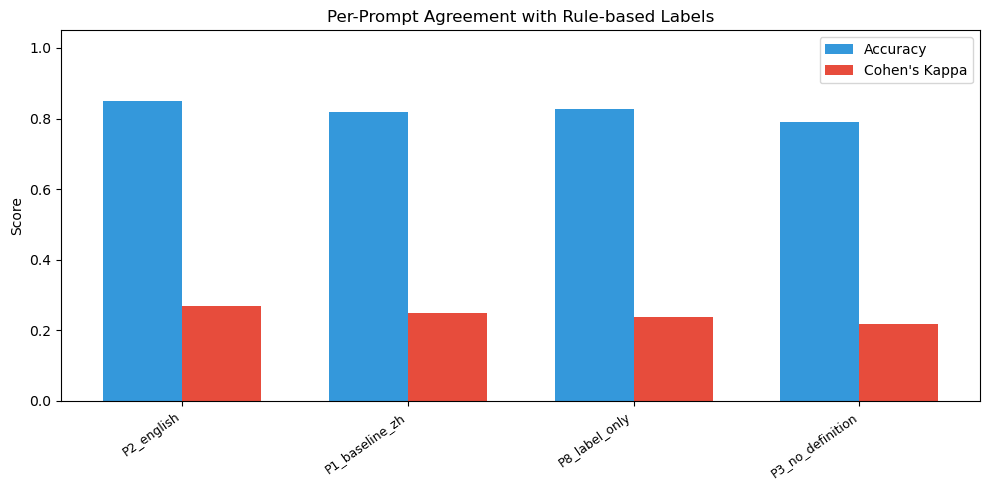

In [33]:
# ====== 2.3 Prompt 间一致性可视化 ======
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df_prompt_metrics))
width = 0.35
ax.bar([i - width/2 for i in x], df_prompt_metrics["accuracy"],
       width, label="Accuracy", color="#3498db")
ax.bar([i + width/2 for i in x], df_prompt_metrics["kappa"],
       width, label="Cohen's Kappa", color="#e74c3c")

ax.set_xticks(list(x))
ax.set_xticklabels(df_prompt_metrics["prompt_id"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Per-Prompt Agreement with Rule-based Labels")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("output/prompt_agreement_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# ====== 2.4 文档级敏感性分析 ======

# 计算每个文档在所有 prompt 下的标签分布
doc_labels = (df_valid.groupby(["doc_idx", "gemini_label"])
              .size().unstack(fill_value=0))
doc_total = doc_labels.sum(axis=1)
doc_majority = doc_labels.max(axis=1)

# Consistency = 多数标签占比
doc_consistency = doc_majority / doc_total

# 多数投票标签
doc_majority_label = doc_labels.idxmax(axis=1)

# PSI = 1 - consistency
doc_psi = 1 - doc_consistency

df_doc_sensitivity = pd.DataFrame({
    "doc_idx": doc_consistency.index,
    "consistency": doc_consistency.values,
    "psi": doc_psi.values,
    "majority_label": doc_majority_label.values,
    "n_prompts": doc_total.values,
}).merge(df[["filename", "tool"]].rename(columns={"tool": "rule_label"}),
         left_on="doc_idx", right_index=True)

print(f"文档级一致性统计:")
print(f"  完全一致 (consistency=1.0): {(doc_consistency == 1.0).sum()} 文档")
print(f"  高度一致 (≥ 0.875):        {(doc_consistency >= 0.875).sum()} 文档")
print(f"  中度分歧 (0.5-0.875):      {((doc_consistency >= 0.5) & (doc_consistency < 0.875)).sum()} 文档")
print(f"  严重分歧 (< 0.5):          {(doc_consistency < 0.5).sum()} 文档")

文档级一致性统计:
  完全一致 (consistency=1.0): 502 文档
  高度一致 (≥ 0.875):        502 文档
  中度分歧 (0.5-0.875):      73 文档
  严重分歧 (< 0.5):          0 文档


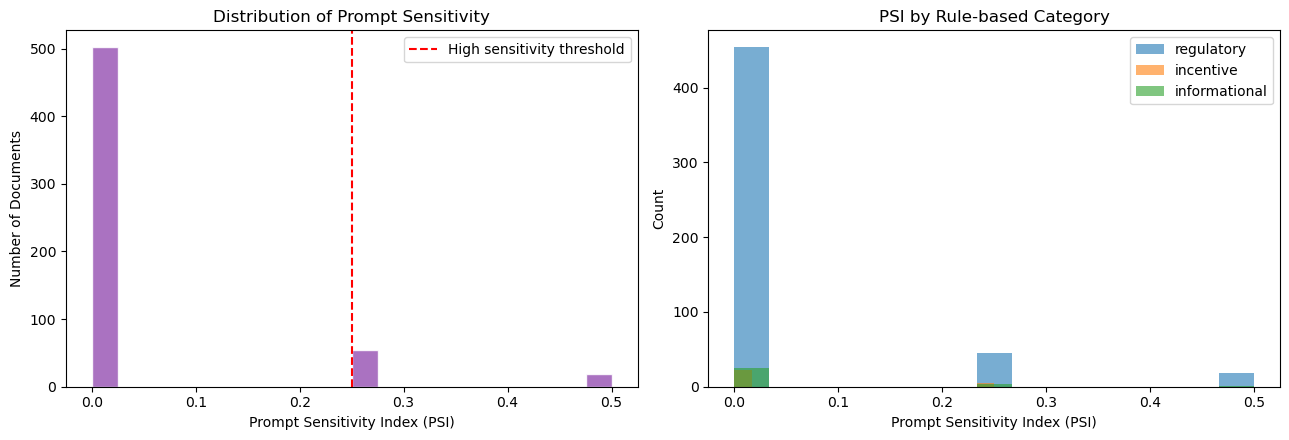

In [35]:
# ====== 2.5 PSI 分布直方图 ======
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# PSI 分布
axes[0].hist(df_doc_sensitivity["psi"], bins=20, color="#9b59b6",
             edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Prompt Sensitivity Index (PSI)")
axes[0].set_ylabel("Number of Documents")
axes[0].set_title("Distribution of Prompt Sensitivity")
axes[0].axvline(x=0.25, color="red", linestyle="--", label="High sensitivity threshold")
axes[0].legend()

# 按规则类别分组的 PSI
for label in LABELS:
    subset = df_doc_sensitivity[df_doc_sensitivity["rule_label"] == label]
    axes[1].hist(subset["psi"], bins=15, alpha=0.6, label=label)
axes[1].set_xlabel("Prompt Sensitivity Index (PSI)")
axes[1].set_ylabel("Count")
axes[1].set_title("PSI by Rule-based Category")
axes[1].legend()

plt.tight_layout()
plt.savefig("output/psi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

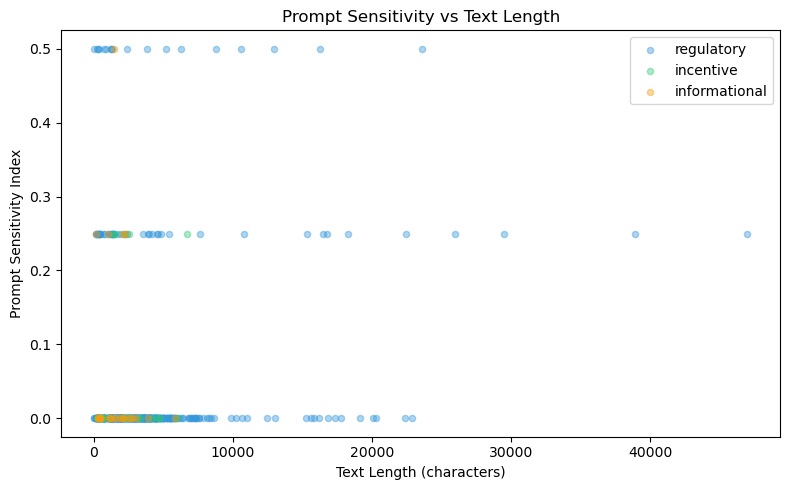

PSI 与文本长度的 Pearson 相关系数: 0.172


In [36]:
# ====== 2.6 PSI 与文本长度的关系 ======
df_doc_sensitivity["text_len"] = df.loc[df_doc_sensitivity["doc_idx"], "clean_text"].str.len().values

fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {"regulatory": "#3498db", "incentive": "#2ecc71", "informational": "#f39c12"}
for label in LABELS:
    subset = df_doc_sensitivity[df_doc_sensitivity["rule_label"] == label]
    ax.scatter(subset["text_len"], subset["psi"], alpha=0.4, s=20,
               color=colors_map[label], label=label)
ax.set_xlabel("Text Length (characters)")
ax.set_ylabel("Prompt Sensitivity Index")
ax.set_title("Prompt Sensitivity vs Text Length")
ax.legend()
plt.tight_layout()
plt.savefig("output/psi_vs_textlen.png", dpi=150, bbox_inches="tight")
plt.show()

# 相关性
corr = df_doc_sensitivity[["psi", "text_len"]].corr().iloc[0, 1]
print(f"PSI 与文本长度的 Pearson 相关系数: {corr:.3f}")

In [37]:
# ====== 2.7 最不稳定的文档 TOP-15 ======
top_unstable = df_doc_sensitivity.sort_values("psi", ascending=False).head(15)
print("最不稳定的 15 篇文档（PSI 最高）：\n")
for _, row in top_unstable.iterrows():
    idx = row["doc_idx"]
    # 获取该文档各 prompt 的标签分布
    doc_data = df_valid[df_valid["doc_idx"] == idx]
    label_dist = doc_data["gemini_label"].value_counts().to_dict()
    print(f"  [{row['filename']}]")
    print(f"    规则={row['rule_label']}, 多数投票={row['majority_label']}, "
          f"PSI={row['psi']:.3f}, 分布={label_dist}")

最不稳定的 15 篇文档（PSI 最高）：

  [2020-关于下达北仑区2020年度工业园区（集聚区）“污水零直排区”建设提升项目的通知.docx]
    规则=regulatory, 多数投票=incentive, PSI=0.500, 分布={'incentive': 2, 'regulatory': 2}
  [2014-青田县人民政府办公室关于印发青田县“五水共治”捐助资金（物资）管理办法的通知.docx]
    规则=regulatory, 多数投票=incentive, PSI=0.500, 分布={'incentive': 2, 'regulatory': 1, 'informational': 1}
  [2023-嵊泗县人民政府关于印发嵊泗县减污降碳协同试点创建实施方案的通知.docx]
    规则=regulatory, 多数投票=informational, PSI=0.500, 分布={'regulatory': 2, 'informational': 2}
  [2014-宁波市鄞州区人民政府办公室关于印发《鄞州区“五水共治”募捐资金使用管理办法》的通知.docx]
    规则=regulatory, 多数投票=incentive, PSI=0.500, 分布={'incentive': 2, 'regulatory': 2}
  [2016-建德市人民政府关于调整居民生活污水处理费标准的通知.docx]
    规则=regulatory, 多数投票=incentive, PSI=0.500, 分布={'incentive': 2, 'regulatory': 2}
  [2023-宁波市江北区人民政府办公室关于印发《江北区农村生活污水治理工作考核办法（试行）》的通知.docx]
    规则=regulatory, 多数投票=incentive, PSI=0.500, 分布={'incentive': 2, 'regulatory': 2}
  [2017-关于印发《嘉兴市南湖区河道综合整治规划》的通知.docx]
    规则=regulatory, 多数投票=informational, PSI=0.500, 分布={'regulatory': 2, 'informational': 2}
  [2023-关于下达202

---
# Phase 3: 规则方法 vs LLM 一致性分析

将两种方法视为两个独立 annotator，使用 **多数投票标签（majority vote）** 作为 LLM 的最终判断。

In [38]:
# 构建对比 DataFrame: rule_label vs majority_label
df_compare = df_doc_sensitivity[["doc_idx", "filename", "rule_label",
                                  "majority_label", "consistency", "psi"]].copy()
df_compare["agree"] = df_compare["rule_label"] == df_compare["majority_label"]

# --- 3.1 总体一致性 ---
acc = accuracy_score(df_compare["rule_label"], df_compare["majority_label"])
kappa = cohen_kappa_score(df_compare["rule_label"], df_compare["majority_label"])

print("=" * 55)
print("  规则方法 vs LLM 多数投票 — 一致性")
print("=" * 55)
print(f"  Agreement Rate: {acc:.4f}")
print(f"  Cohen's Kappa:  {kappa:.4f}")
print(f"  一致文档数:      {df_compare['agree'].sum()} / {len(df_compare)}")
print(f"  分歧文档数:      {(~df_compare['agree']).sum()}")
print("=" * 55)

  规则方法 vs LLM 多数投票 — 一致性
  Agreement Rate: 0.8070
  Cohen's Kappa:  0.2188
  一致文档数:      464 / 575
  分歧文档数:      111


In [39]:
# --- 3.2 分类报告 ---
print("\nClassification Report (Rule as reference):")
print(classification_report(df_compare["rule_label"], df_compare["majority_label"],
                            labels=LABELS, digits=3, zero_division=0))


Classification Report (Rule as reference):
               precision    recall  f1-score   support

   regulatory      0.931     0.857     0.892       517
    incentive      0.162     0.393     0.229        28
informational      0.323     0.333     0.328        30

     accuracy                          0.807       575
    macro avg      0.472     0.528     0.483       575
 weighted avg      0.862     0.807     0.831       575



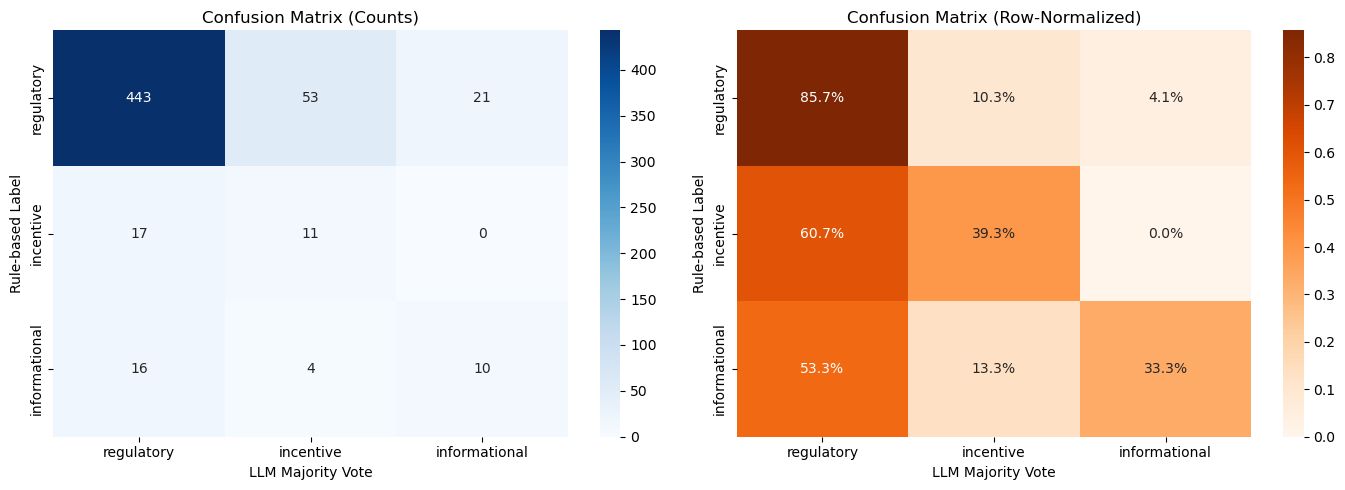

In [40]:
# --- 3.3 混淆矩阵 ---
cm = confusion_matrix(df_compare["rule_label"], df_compare["majority_label"], labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_xlabel("LLM Majority Vote")
axes[0].set_ylabel("Rule-based Label")
axes[0].set_title("Confusion Matrix (Counts)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Oranges",
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
axes[1].set_xlabel("LLM Majority Vote")
axes[1].set_ylabel("Rule-based Label")
axes[1].set_title("Confusion Matrix (Row-Normalized)")

plt.tight_layout()
plt.savefig("output/confusion_matrix_rule_vs_llm.png", dpi=150, bbox_inches="tight")
plt.show()

分歧模式分布：
pattern
regulatory → incentive        53
regulatory → informational    21
incentive → regulatory        17
informational → regulatory    16
informational → incentive      4
Name: count, dtype: int64


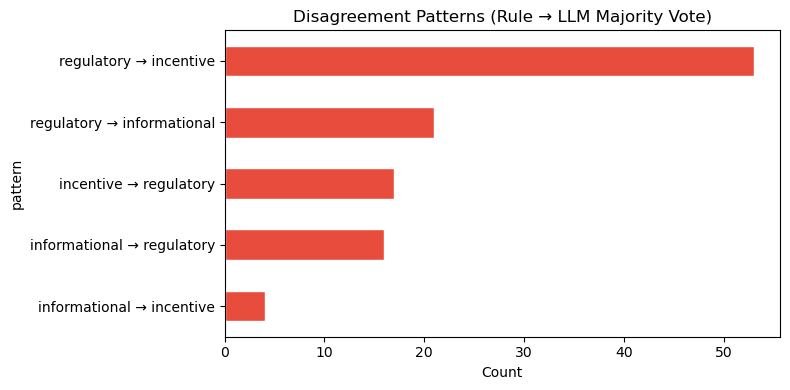

In [41]:
# --- 3.4 分歧模式分析 ---
df_disagree = df_compare[~df_compare["agree"]].copy()
df_disagree["pattern"] = df_disagree["rule_label"] + " → " + df_disagree["majority_label"]

print("分歧模式分布：")
print(df_disagree["pattern"].value_counts())

# 可视化
if len(df_disagree) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    df_disagree["pattern"].value_counts().plot(
        kind="barh", ax=ax, color="#e74c3c", edgecolor="white")
    ax.set_xlabel("Count")
    ax.set_title("Disagreement Patterns (Rule → LLM Majority Vote)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("output/disagreement_patterns.png", dpi=150, bbox_inches="tight")
    plt.show()

In [42]:
# --- 3.5 系统性弱点分析：规则方法的典型失败模式 ---
print("\n=== 规则方法的系统性弱点 ===")
print("\n以下是规则分类为 incentive，但 LLM 多数判为 regulatory 的样本（关键词误导）：\n")

pattern_cases = df_disagree[df_disagree["pattern"] == "incentive → regulatory"]
if len(pattern_cases) == 0:
    pattern_cases = df_disagree[df_disagree["pattern"] == "regulatory → incentive"]

for _, row in pattern_cases.head(5).iterrows():
    idx = row["doc_idx"]
    text_snippet = str(df.loc[idx, "clean_text"])[:250]
    print(f"  文件: {row['filename']}")
    print(f"  规则={row['rule_label']}, LLM={row['majority_label']}, PSI={row['psi']:.3f}")
    print(f"  文本片段: {text_snippet}...")
    # 展示该文档各 prompt 的判断
    doc_results = df_valid[df_valid["doc_idx"] == idx][["prompt_id", "gemini_label"]]
    print(f"  各 Prompt 结果: {dict(zip(doc_results['prompt_id'], doc_results['gemini_label']))}")
    print()


=== 规则方法的系统性弱点 ===

以下是规则分类为 incentive，但 LLM 多数判为 regulatory 的样本（关键词误导）：

  文件: 2014-宁波市鄞州区人民政府办公室关于印发鄞州区农村防洪排涝、农村河道疏浚及小型水库山塘整治三年行动计划.docx
  规则=incentive, LLM=regulatory, PSI=0.000
  文本片段: 宁波市鄞州区人民政府办公室关于印发鄞州区农村防洪排涝农村河道疏浚及小型水库山塘整治三年行动计划各镇乡政府街道办事处区政府各部门直属单位鄞州区农村防洪排涝农村河道疏浚及小型水库山塘整治三年行动计划年已经区政府常务会议审议通过现予以印发请认真贯彻执行宁波市鄞州区人民政府办公室年月日鄞州区农村防洪排涝农村河道疏浚及小型水库山塘整治三年行动计划年为全面贯彻省市五水共治重要决策部署认真落实鄞州区五水共治三年行动计划依托现代水利百亿工程建设平台围绕防洪水排涝水治污水保供水的总体目标要求结合鄞州治水实际特制订...
  各 Prompt 结果: {'P1_baseline_zh': 'regulatory', 'P2_english': 'regulatory', 'P3_no_definition': 'regulatory', 'P8_label_only': 'regulatory'}

  文件: 2018-关于下达2018年度各镇（街道）河道疏浚整治、美丽河道（池塘）建设、保洁计划任务的通知.docx
  规则=incentive, LLM=regulatory, PSI=0.000
  文本片段: 关于下达年度各镇街道河道疏浚整治美丽河道池塘建设保洁计划任务的通知各镇街道人民政府办事处为进一步深入开展五水共治工作加快推进温岭市水环境综合整治全面提升全市水环境质量现将年度河道疏浚整治美丽河道池塘建设保洁长效管理工作计划下达给你们详见附件并就有关事项通知如下一切实维护计划严肃性各地要切实加强领导提高认识精心组织周密部署要结合本地实际以市委市政府部署的五水共治多城同创四边三化城乡环境整治及美丽乡村建设为抓手优先按照成片连线疏浚整治的工作要求充分发挥投入效益彰显规模效益和工作效能切实落实河道疏浚整...
  各 Prompt 结果: {'P1_baseline_zh': 'regulatory', 'P

---
# Phase 4: 导出分歧样本 → 人工标注

将规则方法与 LLM 不一致的样本导出，供研究者手动审查并标注 ground truth。
这批人工标注将用于 Phase 5 的三方评估。

In [43]:
# 构建人工标注表
annotation_rows = []
for _, row in df_disagree.iterrows():
    idx = row["doc_idx"]
    text = str(df.loc[idx, "clean_text"])

    # 获取各 prompt 的判断
    doc_results = df_valid[df_valid["doc_idx"] == idx]
    prompt_labels = dict(zip(doc_results["prompt_id"], doc_results["gemini_label"]))

    # 获取一个代表性理由（从 baseline prompt）
    baseline_reason = ""
    baseline_row = doc_results[doc_results["prompt_id"] == "P1_baseline_zh"]
    if len(baseline_row) > 0:
        baseline_reason = baseline_row.iloc[0]["gemini_reason"]

    annotation_rows.append({
        "doc_idx": idx,
        "filename": row["filename"],
        "city": df.loc[idx, "city"],
        "county": df.loc[idx, "county"],
        "year": df.loc[idx, "year"],
        "rule_label": row["rule_label"],
        "llm_majority_label": row["majority_label"],
        "llm_consistency": row["consistency"],
        "llm_reason": baseline_reason,
        "text_first_500": text[:500],
        "human_label": "",         # <-- 人工填写
        "human_notes": "",         # <-- 人工备注
    })

df_annotation = pd.DataFrame(annotation_rows)
df_annotation.to_csv("output/disagreements_for_annotation.csv",
                      index=False, encoding="utf-8-sig")

print(f"已导出 {len(df_annotation)} 条分歧样本到 output/disagreements_for_annotation.csv")
print(f"\n请手动填写 human_label 列（regulatory / incentive / informational）")
print("完成后保存为 output/human_annotated.csv，然后运行 Phase 5")

已导出 111 条分歧样本到 output/disagreements_for_annotation.csv

请手动填写 human_label 列（regulatory / incentive / informational）
完成后保存为 output/human_annotated.csv，然后运行 Phase 5


In [44]:
# 同时导出一批一致样本作为对照（随机抽取 30 条）
df_agree_samples = df_compare[df_compare["agree"]].sample(
    n=min(30, df_compare["agree"].sum()), random_state=42
)

agree_rows = []
for _, row in df_agree_samples.iterrows():
    idx = row["doc_idx"]
    agree_rows.append({
        "doc_idx": idx,
        "filename": row["filename"],
        "rule_label": row["rule_label"],
        "llm_majority_label": row["majority_label"],
        "text_first_500": str(df.loc[idx, "clean_text"])[:500],
        "human_label": "",
        "human_notes": "",
    })

pd.DataFrame(agree_rows).to_csv("output/agreement_control_samples.csv",
                                 index=False, encoding="utf-8-sig")
print(f"已导出 {len(agree_rows)} 条一致样本（对照组）到 agreement_control_samples.csv")

已导出 30 条一致样本（对照组）到 agreement_control_samples.csv


---
# Phase 5: 三方评估（Human vs Rule vs LLM）

**在完成人工标注后运行本部分。**

以 human-annotated label 为 ground truth，分别评估规则方法和 LLM 多数投票的准确率。
同时分析规则方法的系统性弱点（如关键词误导）。

In [45]:
# ====== 5.0 加载人工标注结果 ======
# 请确保已将标注结果保存为 output/human_annotated.csv
# 该文件应包含: doc_idx, rule_label, llm_majority_label, human_label

HUMAN_PATH = "output/human_annotated.csv"

if not os.path.exists(HUMAN_PATH):
    print("⚠ 尚未找到 human_annotated.csv")
    print("  请先完成 Phase 4 导出的分歧样本标注，保存为 output/human_annotated.csv")
    print("  然后重新运行本节。")
else:
    df_human = pd.read_csv(HUMAN_PATH)
    df_human = df_human[df_human["human_label"].isin(VALID_LABELS)].copy()
    print(f"加载了 {len(df_human)} 条人工标注结果")
    print(f"\n人工标签分布:")
    print(df_human["human_label"].value_counts())

加载了 111 条人工标注结果

人工标签分布:
human_label
regulatory       62
incentive        28
informational    21
Name: count, dtype: int64


In [46]:
# ====== 5.1 三方准确率 ======
if os.path.exists(HUMAN_PATH):
    df_h = pd.read_csv(HUMAN_PATH)
    df_h = df_h[df_h["human_label"].isin(VALID_LABELS)].copy()

    y_human = df_h["human_label"]
    y_rule  = df_h["rule_label"]
    y_llm   = df_h["llm_majority_label"]

    acc_rule = accuracy_score(y_human, y_rule)
    acc_llm  = accuracy_score(y_human, y_llm)
    kappa_rule = cohen_kappa_score(y_human, y_rule)
    kappa_llm  = cohen_kappa_score(y_human, y_llm)

    print("=" * 60)
    print("  三方评估：以 Human Label 为 Ground Truth")
    print("=" * 60)
    print(f"  {'Method':<25} {'Accuracy':>10} {'Kappa':>10}")
    print(f"  {'-'*45}")
    print(f"  {'Rule-based':<25} {acc_rule:>10.4f} {kappa_rule:>10.4f}")
    print(f"  {'LLM Majority Vote':<25} {acc_llm:>10.4f} {kappa_llm:>10.4f}")
    print("=" * 60)
    print(f"\n  样本数: {len(df_h)} (分歧样本)")

  三方评估：以 Human Label 为 Ground Truth
  Method                      Accuracy      Kappa
  ---------------------------------------------
  Rule-based                    0.3694    -0.1365
  LLM Majority Vote             0.5405     0.3128

  样本数: 111 (分歧样本)


In [47]:
# ====== 5.2 分类别对比 ======
if os.path.exists(HUMAN_PATH):
    print("\n=== Rule-based vs Human ===")
    print(classification_report(y_human, y_rule, labels=LABELS, digits=3, zero_division=0))

    print("\n=== LLM Majority Vote vs Human ===")
    print(classification_report(y_human, y_llm, labels=LABELS, digits=3, zero_division=0))


=== Rule-based vs Human ===
               precision    recall  f1-score   support

   regulatory      0.500     0.597     0.544        62
    incentive      0.000     0.000     0.000        28
informational      0.200     0.190     0.195        21

     accuracy                          0.369       111
    macro avg      0.233     0.262     0.246       111
 weighted avg      0.317     0.369     0.341       111


=== LLM Majority Vote vs Human ===
               precision    recall  f1-score   support

   regulatory      0.697     0.371     0.484        62
    incentive      0.456     0.929     0.612        28
informational      0.524     0.524     0.524        21

     accuracy                          0.541       111
    macro avg      0.559     0.608     0.540       111
 weighted avg      0.603     0.541     0.524       111



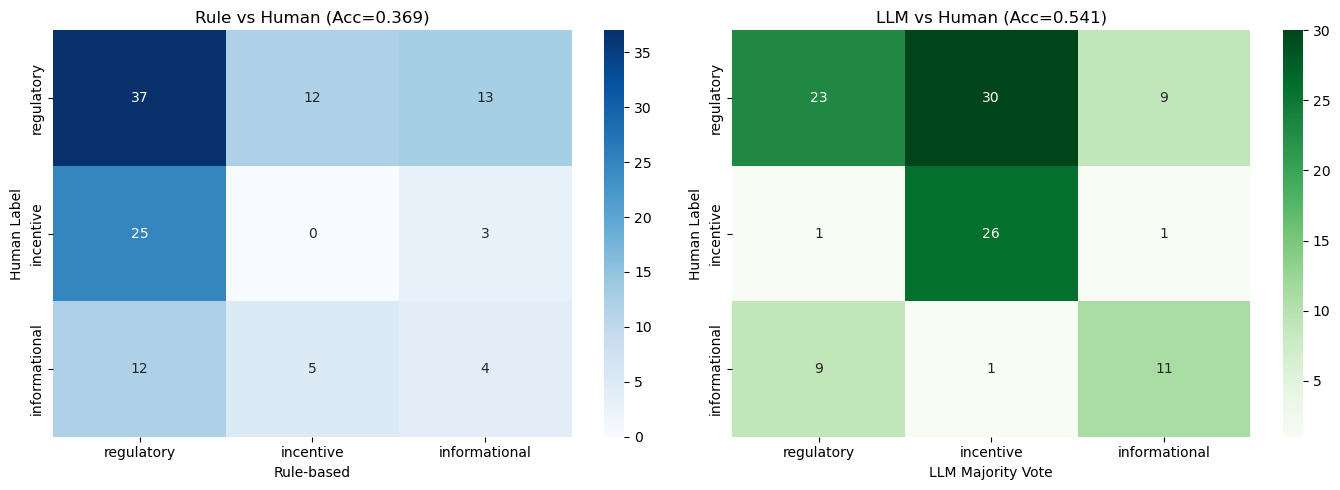

In [48]:
# ====== 5.3 双混淆矩阵（Rule vs Human / LLM vs Human）======
if os.path.exists(HUMAN_PATH):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm_rule = confusion_matrix(y_human, y_rule, labels=LABELS)
    sns.heatmap(cm_rule, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
    axes[0].set_xlabel("Rule-based")
    axes[0].set_ylabel("Human Label")
    axes[0].set_title(f"Rule vs Human (Acc={acc_rule:.3f})")

    cm_llm = confusion_matrix(y_human, y_llm, labels=LABELS)
    sns.heatmap(cm_llm, annot=True, fmt="d", cmap="Greens",
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[1])
    axes[1].set_xlabel("LLM Majority Vote")
    axes[1].set_ylabel("Human Label")
    axes[1].set_title(f"LLM vs Human (Acc={acc_llm:.3f})")

    plt.tight_layout()
    plt.savefig("output/three_way_confusion.png", dpi=150, bbox_inches="tight")
    plt.show()

错误类型归因（在分歧样本上）：
  两者都对:         0 (0.0%)
  仅规则正确:      41 (36.9%)
  仅 LLM 正确:     60 (54.1%)
  两者都错:        10 (9.0%)


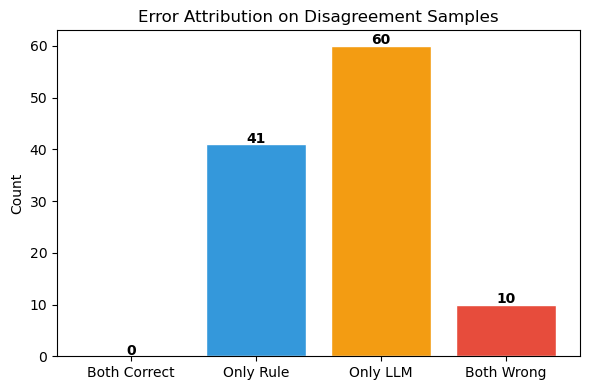

In [49]:
# ====== 5.4 错误类型归因分析 ======
if os.path.exists(HUMAN_PATH):
    df_h["rule_correct"] = df_h["rule_label"] == df_h["human_label"]
    df_h["llm_correct"]  = df_h["llm_majority_label"] == df_h["human_label"]

    # 四种情况
    both_right   = (df_h["rule_correct"] & df_h["llm_correct"]).sum()
    rule_only    = (df_h["rule_correct"] & ~df_h["llm_correct"]).sum()
    llm_only     = (~df_h["rule_correct"] & df_h["llm_correct"]).sum()
    both_wrong   = (~df_h["rule_correct"] & ~df_h["llm_correct"]).sum()

    print("错误类型归因（在分歧样本上）：")
    print(f"  两者都对:      {both_right:>4} ({both_right/len(df_h):.1%})")
    print(f"  仅规则正确:    {rule_only:>4} ({rule_only/len(df_h):.1%})")
    print(f"  仅 LLM 正确:   {llm_only:>4} ({llm_only/len(df_h):.1%})")
    print(f"  两者都错:      {both_wrong:>4} ({both_wrong/len(df_h):.1%})")

    # 可视化
    fig, ax = plt.subplots(figsize=(6, 4))
    categories = ["Both Correct", "Only Rule", "Only LLM", "Both Wrong"]
    values = [both_right, rule_only, llm_only, both_wrong]
    colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]
    ax.bar(categories, values, color=colors, edgecolor="white")
    for i, v in enumerate(values):
        ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_title("Error Attribution on Disagreement Samples")
    plt.tight_layout()
    plt.savefig("output/error_attribution.png", dpi=150, bbox_inches="tight")
    plt.show()

In [50]:
# ====== 5.5 规则方法系统性弱点定性分析 ======
if os.path.exists(HUMAN_PATH):
    # 规则错、LLM 对的样本 —— 说明规则方法的局限
    llm_wins = df_h[~df_h["rule_correct"] & df_h["llm_correct"]].copy()

    if len(llm_wins) > 0:
        print("=== LLM 正确 而 规则错误的样本（规则方法弱点）===\n")
        for _, row in llm_wins.head(10).iterrows():
            idx = row["doc_idx"]
            text_snippet = str(df.loc[idx, "clean_text"])[:200]
            print(f"  文件: {row['filename']}")
            print(f"  Human={row['human_label']}, Rule={row['rule_label']}, LLM={row['llm_majority_label']}")
            if "human_notes" in row and pd.notna(row.get("human_notes")):
                print(f"  人工备注: {row['human_notes']}")
            print(f"  文本: {text_snippet}...")
            print()
    else:
        print("没有'规则错 LLM 对'的样本")

    # 反向：规则对、LLM 错的
    rule_wins = df_h[df_h["rule_correct"] & ~df_h["llm_correct"]]
    if len(rule_wins) > 0:
        print("\n=== 规则正确 而 LLM 错误的样本 ===\n")
        for _, row in rule_wins.head(5).iterrows():
            idx = row["doc_idx"]
            text_snippet = str(df.loc[idx, "clean_text"])[:200]
            print(f"  文件: {row['filename']}")
            print(f"  Human={row['human_label']}, Rule={row['rule_label']}, LLM={row['llm_majority_label']}")
            print(f"  文本: {text_snippet}...")
            print()

=== LLM 正确 而 规则错误的样本（规则方法弱点）===

  文件: 2011-市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知.docx
  Human=incentive, Rule=regulatory, LLM=incentive
  文本: 市政府办公室关于印发城镇污水治理工程建设资金补助与管理办法的通知各镇人民政府各街道办事处市政府各部门各直属单位城镇污水治理工程建设资金补助与管理办法已经市政府同意现印发给你们请认真贯彻执行二一一年六月二十八日城镇污水治理工程建设资金补助与管理办法十二五期间我市将继续大力开展截污纳管和污水治理收集管网工程建设并逐步向农村和边缘地区推进为切实加强列入市级财政补助的污水治理工程项目的建设与管理提高财政资...

  文件: 2019-慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知.docx
  Human=incentive, Rule=regulatory, LLM=incentive
  文本: 慈溪市发展和改革局关于对工业企业超标排放污水实行多因子分档计收污水处理费的通知市水务集团有限公司各镇自来水厂为深化环境价格改革完善工业污水处理费形成机制鼓励和引导企业加大污水处理设施投入和污水处理力度促进五水共治进一步推进水环境改善根据浙江省物价局浙江省财政厅浙江省环境保护厅关于加快推进分类分档及多因子计收工业污水处理费的指导意见浙价资号宁波市物价局宁波市城市管理局关于对市区工业企业超标排放污水实...

  文件: 2016-慈溪市物价局关于调整城市居民生活污水处理费标准的通知.docx
  Human=incentive, Rule=regulatory, LLM=incentive
  文本: 慈溪市物价局关于调整城市居民生活污水处理费标准的通知市水务集团有限公司根据国家发展改革委财政部住房城乡建设部关于制定和调整污水处理收费标准等有关问题的通知发改价格号等有关规定结合本市实际经市政府同意决定调整城市居民生活污水处理费标准现将有关事项通知如下一居民污水处理费调整范围和性质市自来水有限公司直接抄表管理的城市居民用户二城市居民污水处理费调整标准由现行元立方米高层二次供水用户趸售元立方米调整为...

  文件: 2013-慈溪市发展和改革局关于调整非居民生活用水污水处理费

---
# Phase 6: 标签分布对比与最终汇总

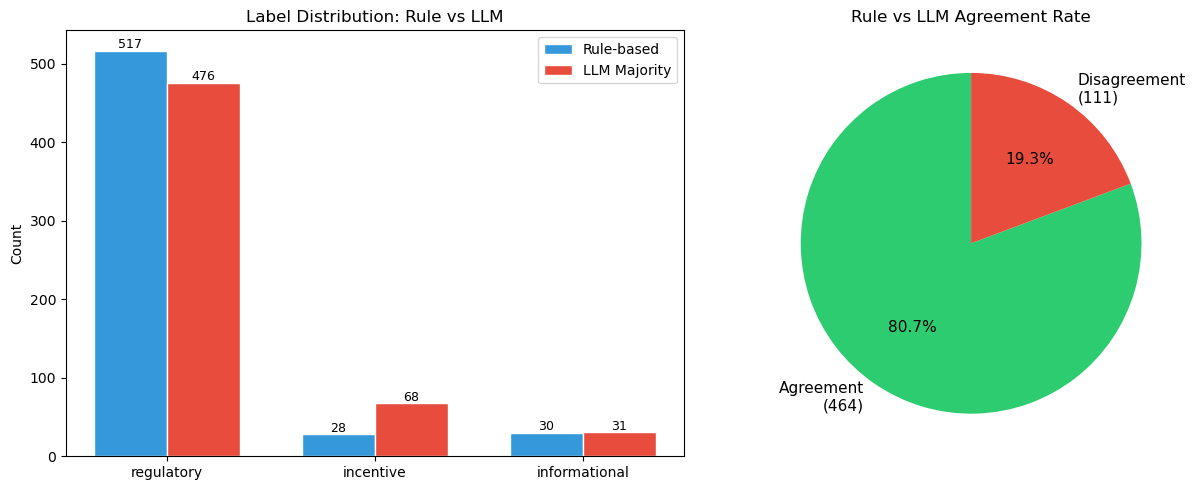

In [51]:
# ====== 6.1 全局标签分布对比 ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

color_list = ["#3498db", "#2ecc71", "#f39c12"]

# 分布对比
rule_counts = df_compare["rule_label"].value_counts().reindex(LABELS, fill_value=0)
llm_counts = df_compare["majority_label"].value_counts().reindex(LABELS, fill_value=0)

x = np.arange(len(LABELS))
w = 0.35
axes[0].bar(x - w/2, rule_counts, w, label="Rule-based", color="#3498db", edgecolor="white")
axes[0].bar(x + w/2, llm_counts, w, label="LLM Majority", color="#e74c3c", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABELS)
axes[0].set_ylabel("Count")
axes[0].set_title("Label Distribution: Rule vs LLM")
axes[0].legend()
for i in range(len(LABELS)):
    axes[0].text(i - w/2, rule_counts.iloc[i] + 3, str(rule_counts.iloc[i]),
                 ha="center", fontsize=9)
    axes[0].text(i + w/2, llm_counts.iloc[i] + 3, str(llm_counts.iloc[i]),
                 ha="center", fontsize=9)

# 一致 vs 分歧 饼图
agree_count = df_compare["agree"].sum()
disagree_count = (~df_compare["agree"]).sum()
axes[1].pie([agree_count, disagree_count],
            labels=[f"Agreement\n({agree_count})", f"Disagreement\n({disagree_count})"],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Rule vs LLM Agreement Rate")

plt.tight_layout()
plt.savefig("output/label_distribution_summary.png", dpi=150, bbox_inches="tight")
plt.show()

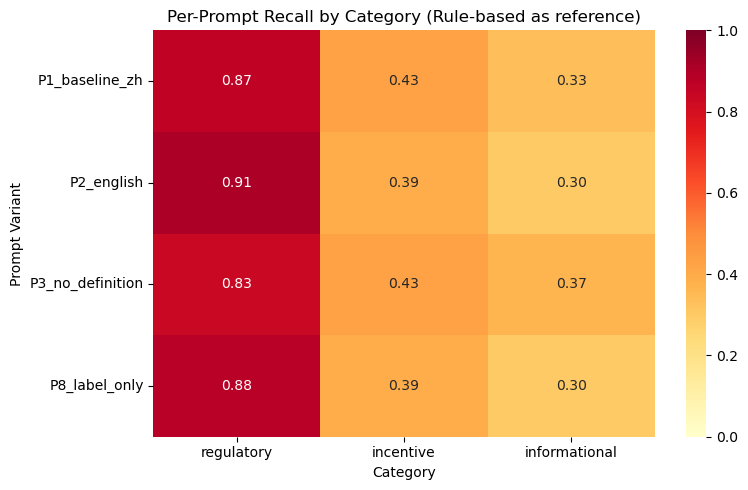

In [52]:
# ====== 6.2 各 Prompt 对每个类别的 recall（热力图）======
# 展示不同 prompt 对 incentive / informational 少数类的识别差异

recall_data = []
for pid in SELECTED_PROMPTS:
    subset = df_valid[df_valid["prompt_id"] == pid]
    if len(subset) == 0:
        continue
    for label in LABELS:
        mask = subset["rule_label"] == label
        if mask.sum() == 0:
            recall_data.append({"prompt": pid, "class": label, "recall": 0})
        else:
            recall = (subset.loc[mask, "gemini_label"] == label).mean()
            recall_data.append({"prompt": pid, "class": label, "recall": recall})

df_recall = pd.DataFrame(recall_data).pivot(index="prompt", columns="class", values="recall")
df_recall = df_recall[LABELS]  # reorder columns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_recall, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=ax)
ax.set_title("Per-Prompt Recall by Category (Rule-based as reference)")
ax.set_ylabel("Prompt Variant")
ax.set_xlabel("Category")
plt.tight_layout()
plt.savefig("output/prompt_recall_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# ====== 6.3 完整结果导出 ======
df_final = df.copy()
df_final = df_final.merge(
    df_doc_sensitivity[["doc_idx", "majority_label", "consistency", "psi"]],
    left_index=True, right_on="doc_idx", how="left"
)
df_final["agree"] = df_final["tool"] == df_final["majority_label"]

df_final.to_csv("output/policy_full_results.csv", index=False, encoding="utf-8-sig")
print("已保存完整结果到 output/policy_full_results.csv")

已保存完整结果到 output/policy_full_results.csv


In [54]:
# ====== 6.4 最终汇总 ======
print("\n" + "=" * 65)
print("                     研究结果汇总")
print("=" * 65)
print(f"\n【数据规模】")
print(f"  文档数: {len(df)}")
print(f"  Prompt 变体数: {len(PROMPTS)}")
print(f"  总分类次数: {len(df_valid)} (有效)")

print(f"\n【Prompt 敏感性】")
print(f"  完全一致文档: {(doc_consistency == 1.0).sum()} ({(doc_consistency == 1.0).mean():.1%})")
print(f"  平均 PSI: {doc_psi.mean():.3f}")
print(f"  高敏感文档 (PSI>0.25): {(doc_psi > 0.25).sum()}")
acc_range = df_prompt_metrics["accuracy"]
print(f"  Accuracy 变动范围: {acc_range.min():.3f} ~ {acc_range.max():.3f} "
      f"(Δ={acc_range.max()-acc_range.min():.3f})")

print(f"\n【规则 vs LLM 一致性】")
print(f"  Agreement Rate: {acc:.4f}")
print(f"  Cohen's Kappa:  {kappa:.4f}")
print(f"  分歧文档数: {(~df_compare['agree']).sum()}")

if os.path.exists(HUMAN_PATH):
    print(f"\n【三方评估 (分歧样本上)】")
    print(f"  Rule vs Human Accuracy:  {acc_rule:.4f}")
    print(f"  LLM  vs Human Accuracy:  {acc_llm:.4f}")
    print(f"  仅 LLM 正确: {llm_only}, 仅 Rule 正确: {rule_only}")

print(f"\n【输出文件】")
outputs = [
    "multi_prompt_results.csv        — 所有 prompt × 文档的原始分类结果",
    "disagreements_for_annotation.csv — 分歧样本（待人工标注）",
    "agreement_control_samples.csv   — 一致样本对照组",
    "policy_full_results.csv         — 合并后完整结果",
    "prompt_agreement_comparison.png — Prompt 变体一致性对比",
    "psi_distribution.png            — 文档级敏感性分布",
    "psi_vs_textlen.png              — PSI 与文本长度关系",
    "confusion_matrix_rule_vs_llm.png — 混淆矩阵",
    "disagreement_patterns.png       — 分歧模式",
    "prompt_recall_heatmap.png       — 各 Prompt 分类别 Recall",
    "label_distribution_summary.png  — 标签分布汇总",
]
if os.path.exists(HUMAN_PATH):
    outputs.extend([
        "three_way_confusion.png        — 三方混淆矩阵",
        "error_attribution.png          — 错误归因",
    ])
for f in outputs:
    print(f"  output/{f}")
print("=" * 65)


                     研究结果汇总

【数据规模】
  文档数: 575
  Prompt 变体数: 8
  总分类次数: 2300 (有效)

【Prompt 敏感性】
  完全一致文档: 502 (87.3%)
  平均 PSI: 0.040
  高敏感文档 (PSI>0.25): 19
  Accuracy 变动范围: 0.790 ~ 0.850 (Δ=0.061)

【规则 vs LLM 一致性】
  Agreement Rate: 0.8070
  Cohen's Kappa:  0.2188
  分歧文档数: 111

【三方评估 (分歧样本上)】
  Rule vs Human Accuracy:  0.3694
  LLM  vs Human Accuracy:  0.5405
  仅 LLM 正确: 60, 仅 Rule 正确: 41

【输出文件】
  output/multi_prompt_results.csv        — 所有 prompt × 文档的原始分类结果
  output/disagreements_for_annotation.csv — 分歧样本（待人工标注）
  output/agreement_control_samples.csv   — 一致样本对照组
  output/policy_full_results.csv         — 合并后完整结果
  output/prompt_agreement_comparison.png — Prompt 变体一致性对比
  output/psi_distribution.png            — 文档级敏感性分布
  output/psi_vs_textlen.png              — PSI 与文本长度关系
  output/confusion_matrix_rule_vs_llm.png — 混淆矩阵
  output/disagreement_patterns.png       — 分歧模式
  output/prompt_recall_heatmap.png       — 各 Prompt 分类别 Recall
  output/label_distribution_summary.png  — 标签分布汇总
 

# Results, Analysis, and Discussion

## 3. Results

### 3.1 Prompt Sensitivity Analysis

We evaluated 575 policy documents across four prompt variants, yielding 2,300 classification instances (all successfully parsed). The four prompts were designed to probe sensitivity along three orthogonal dimensions:

| Prompt ID | Language | Definitions | Output Format |
|-----------|----------|-------------|---------------|
| P1_baseline_zh | Chinese | Detailed + role framing | JSON with reason |
| P2_english | English | Detailed | JSON with reason |
| P3_no_definition | Chinese | Label names only | JSON with reason |
| P8_label_only | Chinese | Brief | Single word |

**Per-prompt label distributions.** The four prompts produced notably different label distributions, particularly for minority classes. P1 (baseline) and P3 (no definition) assigned *incentive* most frequently (72 and 71 documents respectively), while P2 (English) was more conservative (51 documents). All prompts assigned far more *incentive* labels than the rule-based classifier (28 documents), indicating that the LLM consistently identifies more incentive-type policy instruments than the keyword-based approach.

| Prompt | regulatory | incentive | informational |
|--------|-----------|-----------|---------------|
| P1_baseline_zh | 479 | 72 | 24 |
| P2_english | 505 | 51 | 19 |
| P3_no_definition | 461 | 71 | 43 |
| P8_label_only | 489 | 56 | 30 |
| Rule-based | 517 | 28 | 30 |

**Per-prompt agreement with rule-based labels.** Using the existing rule-based labels as a reference, accuracy ranged from 0.790 (P3) to 0.850 (P2), a spread of Δ = 0.061. Cohen's Kappa ranged from 0.218 to 0.268. Interestingly, the English prompt (P2) achieved the highest accuracy (0.850) and Kappa (0.268), while the no-definition prompt (P3) scored lowest on both metrics. This is because P2's label distribution is closest to the rule-based distribution (both conservative in assigning minority classes), not necessarily because P2 is more accurate in an absolute sense.

| Prompt | Accuracy | Kappa | Macro F1 |
|--------|----------|-------|----------|
| P2_english | 0.850 | 0.268 | 0.521 |
| P1_baseline_zh | 0.817 | 0.248 | 0.503 |
| P8_label_only | 0.826 | 0.237 | 0.489 |
| P3_no_definition | 0.790 | 0.218 | 0.475 |

**Document-level stability.** Using the Prompt Sensitivity Index (PSI = 1 − consistency, where consistency is the proportion of prompts assigning the majority label), we found that 502 documents (87.3%) received a fully consistent label across all four prompts (PSI = 0). The average PSI was 0.040, indicating generally high stability. However, 19 documents had PSI > 0.25 (the maximum possible with 4 prompts is 0.50), and these high-sensitivity documents were disproportionately concentrated among documents where the rule-based label was *regulatory* but the LLM majority vote was *incentive* or *informational* — precisely the boundary cases most prone to classification ambiguity.

Among the 15 most unstable documents (all with PSI = 0.50, meaning a perfect 2-2 split across prompts), several exhibited the "keyword-context mismatch" pattern: documents such as "五水共治捐助资金管理办法" (Management Measures for Five Waters Co-governance Donation Funds) and "污水处理费标准调整通知" (Notice on Adjusting Sewage Treatment Fee Standards) contain financial terminology but serve primarily regulatory or informational functions.

**Relationship with text length.** We observed a weak positive correlation between PSI and text length (Pearson r = 0.172), suggesting that longer documents, which tend to mention a wider variety of policy instruments, are slightly more prone to classification instability across prompts.

### 3.2 Rule-based vs. LLM Agreement (Annotator Agreement Study)

Treating the rule-based classifier and the LLM majority vote as two independent annotators, we measured their inter-annotator agreement across all 575 documents.

**Overall agreement.** The two methods agreed on 464 documents (80.7%), with Cohen's Kappa = 0.219, indicating only fair agreement. The relatively low Kappa despite the high raw agreement is attributable to the extreme class imbalance — the rule-based classifier assigns 517/575 documents (89.9%) to *regulatory*, inflating chance agreement.

**Disagreement patterns.** Of the 111 disagreement cases, the dominant pattern was *regulatory → incentive* (53 cases): the rule-based method classified these as regulatory, but the LLM majority vote classified them as incentive. The second most common pattern was *regulatory → informational* (21 cases). In the reverse direction, 17 cases were classified as *incentive* by the rule and *regulatory* by the LLM, and 16 cases shifted from *informational* to *regulatory*.

| Pattern (Rule → LLM) | Count |
|-----------------------|-------|
| regulatory → incentive | 53 |
| regulatory → informational | 21 |
| incentive → regulatory | 17 |
| informational → regulatory | 16 |
| informational → incentive | 4 |

The concentration of disagreements along the regulatory–incentive boundary reveals the core challenge: policy documents frequently mention both administrative mechanisms and financial instruments, and the two methods differ fundamentally in how they resolve this ambiguity.

### 3.3 Three-Way Evaluation with Human Ground Truth

We manually annotated all 111 disagreement cases to determine which method more accurately captures the dominant policy instrument. The human annotator classified these documents following the established policy instrument framework, with particular attention to distinguishing "providing incentives" from "regulating incentive programs."

**Human label distribution on disagreement samples:**

| Label | Count |
|-------|-------|
| regulatory | 62 |
| incentive | 28 |
| informational | 21 |

**Accuracy comparison.** With human annotation as ground truth:

| Method | Accuracy | Cohen's Kappa |
|--------|----------|---------------|
| Rule-based | 0.369 | −0.137 |
| LLM Majority Vote | 0.541 | 0.313 |

The LLM outperformed the rule-based method by 17.2 percentage points in accuracy. The rule-based method achieved a negative Kappa (−0.137), indicating its classifications on disagreement cases are systematically worse than chance — a strong signal of structural failure rather than random noise.

**Per-class performance.**

| | Rule-based | | | LLM Majority Vote | | |
|---|---|---|---|---|---|---|
| Class | Precision | Recall | F1 | Precision | Recall | F1 |
| regulatory | 0.500 | 0.597 | 0.544 | 0.697 | 0.371 | 0.484 |
| incentive | 0.000 | 0.000 | 0.000 | 0.456 | 0.929 | 0.612 |
| informational | 0.200 | 0.190 | 0.195 | 0.524 | 0.524 | 0.524 |

The most striking finding is that the rule-based classifier achieved F1 = 0 on incentive documents in the disagreement set (0/28 correct), while the LLM achieved F1 = 0.612 with 92.9% recall (26/28 correct). For informational documents, the LLM also demonstrated substantially better performance (F1 = 0.524 vs. 0.195).

**Error attribution.** Across the 111 disagreement cases:

| Category | Count | Proportion |
|----------|-------|------------|
| Both correct | 0 | 0.0% |
| Only rule-based correct | 41 | 36.9% |
| Only LLM correct | 60 | 54.1% |
| Both wrong | 10 | 9.0% |

The LLM was exclusively correct in 60 cases versus 41 for the rule-based method, yielding a net advantage of 19 cases. The zero in "both correct" is expected since we are analyzing only samples where the two methods disagree.

---

## 4. Analysis and Discussion

### 4.1 Systematic Failure of Keyword-Based Classification

The most significant finding is the complete failure of the rule-based classifier on incentive documents within the disagreement set (F1 = 0). Qualitative analysis of the 60 cases where only the LLM was correct reveals a recurring mechanism that we term the **"keyword-context mismatch"**: the rule-based classifier relies on surface-level keyword matching (e.g., "资金" [funds], "补助" [subsidy], "补贴" [subsidy]) to assign labels, but these keywords frequently appear in documents whose dominant policy mechanism is actually different from what the keywords suggest.

Several representative examples illustrate this pattern:

- **"城镇污水治理工程建设资金补助与管理办法"** (Measures for Capital Subsidies and Management of Urban Sewage Treatment Projects): The rule-based classifier identifies "资金" and "补助" and assigns *regulatory* (its default), but the human annotator labels it *incentive* because the document's core purpose is establishing a subsidy program. The LLM correctly identifies this as incentive.
- **"工业企业超标排放污水实行多因子分档计收污水处理费"** (Multi-factor Tiered Collection of Sewage Treatment Fees for Industrial Enterprises Exceeding Emission Standards): Both "排放" (emissions) and "污水处理费" (sewage treatment fees) appear. The rule-based classifier sees regulatory keywords and assigns *regulatory*, but the document's dominant mechanism is an economic pricing instrument — the LLM correctly identifies it as *incentive*.
- **"调整城市居民生活污水处理费标准"** (Adjusting Urban Residential Sewage Treatment Fee Standards): A fee adjustment notice is fundamentally a market-based instrument, but the rule-based classifier misses this because its keyword dictionary does not adequately cover pricing mechanisms.

This keyword-context mismatch is a fundamental limitation of bag-of-words approaches for policy instrument classification. The distinction between "providing incentives" and "regulating how incentives are administered" requires understanding discourse-level semantics that keyword matching cannot capture.

### 4.2 LLM Strengths: Contextual Understanding of Policy Instruments

The LLM's superior performance on incentive (F1 = 0.612 vs. 0.000) and informational (F1 = 0.524 vs. 0.195) classes can be attributed to its ability to identify the dominant policy mechanism rather than simply detecting the presence of relevant vocabulary. We observed three categories where the LLM demonstrated this advantage:

1. **Fee-based instruments**: Documents adjusting sewage treatment fees or establishing tiered pricing structures were correctly identified as incentive by the LLM, even though they contain regulatory language about compliance and enforcement.
2. **Grant management programs**: Documents establishing subsidy programs for pollution treatment infrastructure were recognized as incentive instruments, while the rule-based classifier often defaulted to regulatory.
3. **Information dissemination and planning documents**: Ecological flow management plans, river basin planning documents, and environmental monitoring reports were more frequently identified as informational by the LLM.

### 4.3 LLM Weaknesses: Over-Classification of Incentive

Despite its overall advantage, the LLM exhibited a notable weakness: it classified 30 human-judged *regulatory* documents as *incentive* (out of 62 regulatory cases in the disagreement set), yielding only 37.1% recall for regulatory documents. The confusion matrix shows that the LLM's primary error mode is over-predicting *incentive* at the expense of *regulatory*.

This over-classification pattern is visible in the prompt-level label distributions: all four prompts assigned 51–72 *incentive* labels versus only 28 in the rule-based system and 28 in the human annotation of disagreement cases. The LLM appears to be overly sensitive to financial terminology even when the regulatory context is dominant.

This bias may be partially attributable to the prompt design, which explicitly describes incentive instruments using Chinese financial terminology. Future work could investigate whether adjusting the prompt to emphasize the distinction between "providing incentives" (the policy's purpose) and "mentioning financial mechanisms" (incidental content) reduces this confusion.

### 4.4 Prompt Sensitivity: Variation Within a Robust Framework

Our multi-prompt analysis reveals that while LLM classification is generally stable (87.3% of documents fully consistent, average PSI = 0.040), prompt design choices produce measurable variation:

1. **Definitions matter most**: The accuracy spread between the best prompt (P2, 0.850) and worst (P3, 0.790) is Δ = 0.061. Prompts with detailed category definitions consistently outperform the minimal prompt (P3), suggesting that zero-shot classification benefits substantially from in-context definitional guidance.
2. **Language has a nuanced effect**: The English prompt (P2) achieved the highest agreement with rule-based labels, but this reflects P2's conservative tendency to classify documents as *regulatory* (505/575) rather than superior accuracy. In the three-way evaluation, this conservatism would likely underperform compared to P1's more balanced distribution.
3. **Output format has limited effect**: The label-only format (P8) performed comparably to JSON-structured output (Kappa 0.237 vs. 0.248), indicating that classification accuracy is primarily driven by system-level framing rather than output constraints.

The 19 high-PSI documents (PSI > 0.25) represent the most informative cases for understanding prompt sensitivity. These documents are characterized by mixed policy instruments where the dominant mechanism is genuinely ambiguous — documents like "减污降碳协同试点创建实施方案" (Implementation Plan for Pollution Reduction and Carbon Reduction Synergy Pilot) received a perfect 2-2 split across prompts. Using majority vote across multiple prompts provides a natural robustness mechanism, and high-PSI documents can be flagged for human review.

### 4.5 Implications for Policy Text Analysis

Our findings have practical implications for researchers conducting large-scale policy text analysis:

1. **Rule-based classifiers should not be assumed reliable for multi-class policy instrument classification**, particularly when categories share surface-level vocabulary. In our study, the rule-based method achieved a negative Kappa on disagreement cases, indicating systematic failure.
2. **LLM zero-shot classification provides a viable alternative** that substantially improves classification of minority classes (incentive F1: 0.612 vs. 0.000; informational F1: 0.524 vs. 0.195), though it introduces prompt sensitivity as a new source of variation.
3. **A hybrid workflow is recommended**: use LLM classification as the primary method, apply majority voting across multiple prompts for robustness, and flag high-PSI documents for human review. This combines the scalability of automated classification with the accuracy of human judgment where it matters most.
4. **Human annotation remains essential** as a calibration step. The 9.0% of cases where both methods were wrong underscores the inherent ambiguity of policy instrument classification and the need for domain expertise.

### 4.6 Limitations

Several limitations should be noted. First, our human annotation was conducted by a single annotator; multi-annotator agreement (with inter-rater reliability metrics such as Krippendorff's alpha) would strengthen the ground truth. Second, the three-way evaluation was conducted only on the 111 disagreement cases (19.3% of the full dataset). On the remaining 464 agreement cases, both methods likely perform well, so the full-dataset accuracy gap between rule-based and LLM is expected to be smaller than the 17.2 percentage points observed on disagreements. Third, our analysis is scoped to Chinese water pollution governance policies from Zhejiang Province; generalizability to other policy domains, languages, or governance contexts remains to be established. Fourth, we used a single LLM (Gemini 2.5 Flash) with four prompt variants; comparative evaluation across multiple LLMs and a broader prompt space would provide further insight into model-specific biases and prompt robustness. Finally, we truncated policy texts to 3,000 characters for API efficiency, which may have caused information loss for the longest documents (the maximum text length was 46,983 characters).
